In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/Uncertainty_main')

endpoint_list = config['columns']['labels']

endpoint_list

src\config_presets\Base_config.yaml
src\config_presets\Daniel/Uncertainty_main.yaml


['Dysphagia_M06']

In [2]:

ALL_DFS_DICT = {
     "Dysphagia_M06" : {
        "MC Dropout": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Tune MC Dysphagia/20/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Deep Ensemble/Dysphagia_M06/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/TTA/Dysphagia_M06/model_1/all_predictions.csv", sep=';'),
    },
   'Xerostomia_M06' : {
       "MC Dropout": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Tune MC Xerostomia/20/model_1/all_predictions.csv", sep=';'),
       "Deep Ensemble": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Deep Ensemble/Xerostomia_M06/all_predictions.csv", sep=';'),
       "TTA": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/TTA/Xerostomia_M06/model_1/all_predictions.csv", sep=';'),
   },
   'OS_2year_censored' : {
        "MC Dropout": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Tune MC OS/10/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Deep Ensemble/OS/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/TTA/OS/model_1/all_predictions.csv", sep=';'),
            },
    'LRC_2year_censored' : {
            "MC Dropout": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Tune MC LRC/10/model_1/all_predictions.csv", sep=';'),
            "Deep Ensemble": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/Deep Ensemble/LRC/all_predictions.csv", sep=';'),
            "TTA": pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\2. Results\Models\UQ/TTA/LRC/model_1/all_predictions.csv", sep=';'),
                },    

}

In [3]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance


UQ_RESULTS_DICT = {
    "Dysphagia_M06": {},
    "Xerostomia_M06" : {},
    "OS_2year_censored": {},
    "LRC_2year_censored": {},
    #"Sticky_M06": {},
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary",
    #"Sticky_M06": "Binary",
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    # all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())    

    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)
    #print(df.columns)
    df_UQ_results['Mean Prediction'] = mean_endpoint_preds
    df_UQ_results['PatientID']= df.PatientID

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


def compute_AUC_per_endpoint(df, endpoint):
    from sklearn.metrics import roc_auc_score

    if ENDPOINT_TYPES[endpoint] == "Binary":
        auc = roc_auc_score(df['True Labels'], df['Mean Prediction'])
    else:
        auc = roc_auc_score(df['True Label Event'], df['Mean Prediction'])

    return auc

for endpoint, dfs in ALL_DFS_DICT.items():

    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        # df_all_preds = df_all_preds[df_all_preds[f"{endpoint}_true"] != -1]

        #print(df_all_preds.head())

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results

        df_non_missing = df_UQ_results[df_UQ_results['True Labels'] != -1]

        auc = compute_AUC_per_endpoint(df_non_missing, endpoint)
        print(f"Endpoint: {endpoint}, Method: {method}, AUC: {auc:.2f}          ", len(df_non_missing))
        #print(len(df_non_missing))

    


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA'] # , "Conformal", "Conformal_2"]


# UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

# UQ_methods_list = ["no affine", "no flip", "no noise", "no random_crop", "no rotate", "only rigid"]


Endpoint: Dysphagia_M06, Method: MC Dropout, AUC: 0.86           241
Endpoint: Dysphagia_M06, Method: Deep Ensemble, AUC: 0.87           241
Endpoint: Dysphagia_M06, Method: TTA, AUC: 0.80           241
Endpoint: Xerostomia_M06, Method: MC Dropout, AUC: 0.71           241
Endpoint: Xerostomia_M06, Method: Deep Ensemble, AUC: 0.72           241
Endpoint: Xerostomia_M06, Method: TTA, AUC: 0.71           241
Endpoint: OS_2year_censored, Method: MC Dropout, AUC: 0.74           82
Endpoint: OS_2year_censored, Method: Deep Ensemble, AUC: 0.73           82
Endpoint: OS_2year_censored, Method: TTA, AUC: 0.72           82
Endpoint: LRC_2year_censored, Method: MC Dropout, AUC: 0.62           78
Endpoint: LRC_2year_censored, Method: Deep Ensemble, AUC: 0.57           78
Endpoint: LRC_2year_censored, Method: TTA, AUC: 0.64           78


In [24]:

def replace_legend(fig):

    # collect legend entries from all axes and place a single legend across the bottom
    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)



    if labels:
        # keep first occurrence of each label to avoid duplicates while preserving order
        unique = {}
        for h, l in zip(handles, labels):
            if l not in unique:
                unique[l] = h
        handles = list(unique.values())
        labels = list(unique.keys())

        # remove figure suptitle if present
        st = getattr(fig, "_suptitle", None)
        if st is not None:
            try:
                st.remove()
            except Exception:
                pass

        # make room at top and place legend centered across the figure
        fig.subplots_adjust(top=0.85)
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=len(labels), frameon=True, title = "Uncertainty Measure")
        fig.canvas.draw_idle()

    return fig

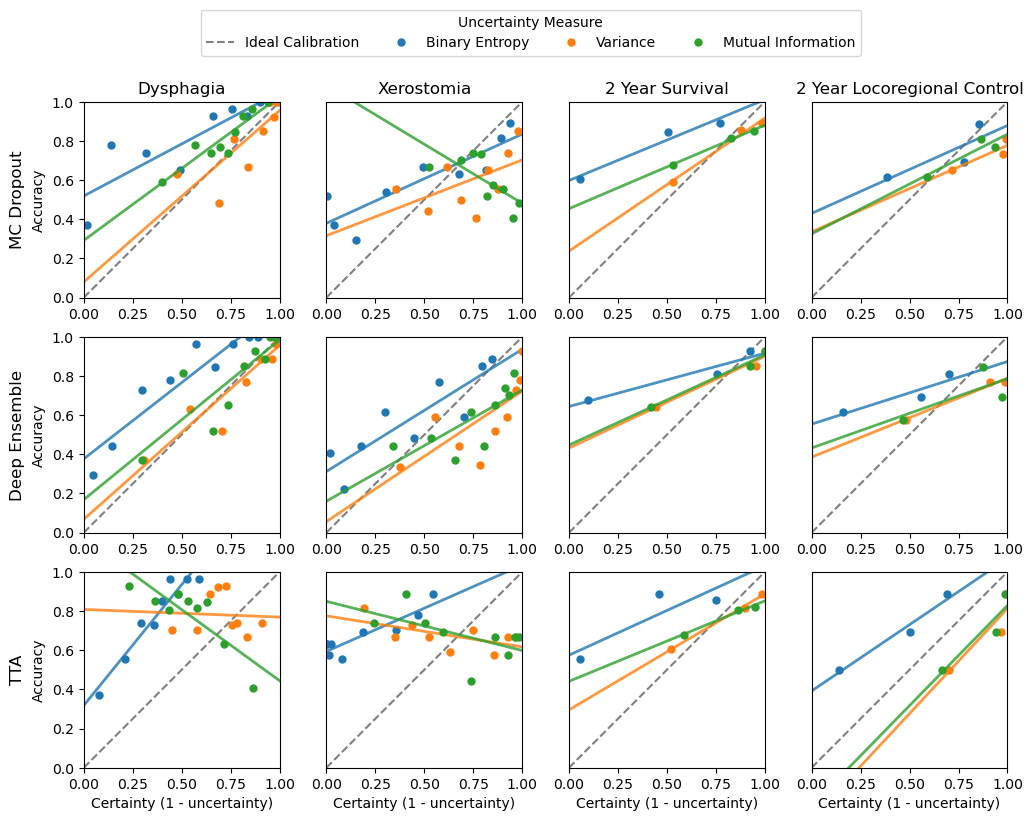

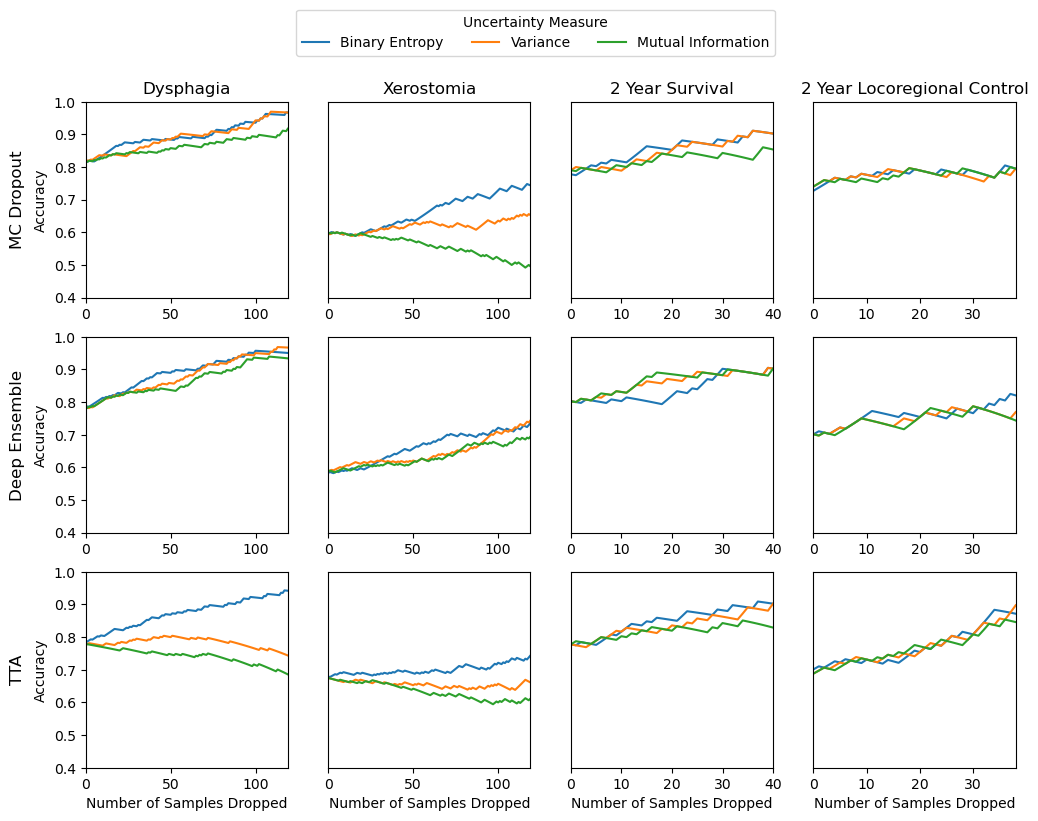

In [31]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ


# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="error calibration", row_key="method", col_key="endpoint", N_bins=5)
# plt.show()

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="prediction_calibration", row_key="method", 
#                      col_key="endpoint", N_bins=5, normalisation_method=None) # predictions
# fig = replace_legend(fig)

# plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="UQ_calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax") # predictions
fig = replace_legend(fig)

fig.savefig("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/5. Uncertainty/2. Results/Plots/UQ_calibration_all_methods.png", dpi=600, bbox_inches='tight')
fig.savefig("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/5. Uncertainty/2. Results/Plots/UQ_calibration_all_methods.tiff", bbox_inches='tight')
plt.show()



fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="method", col_key="endpoint")
fig = replace_legend(fig)

fig.savefig("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/5. Uncertainty/2. Results/Plots/sparsification_all_methods.png", dpi=600, bbox_inches='tight')
fig.savefig("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/5. Uncertainty/2. Results/Plots/sparsification_all_methods.tiff", bbox_inches='tight')
plt.show()


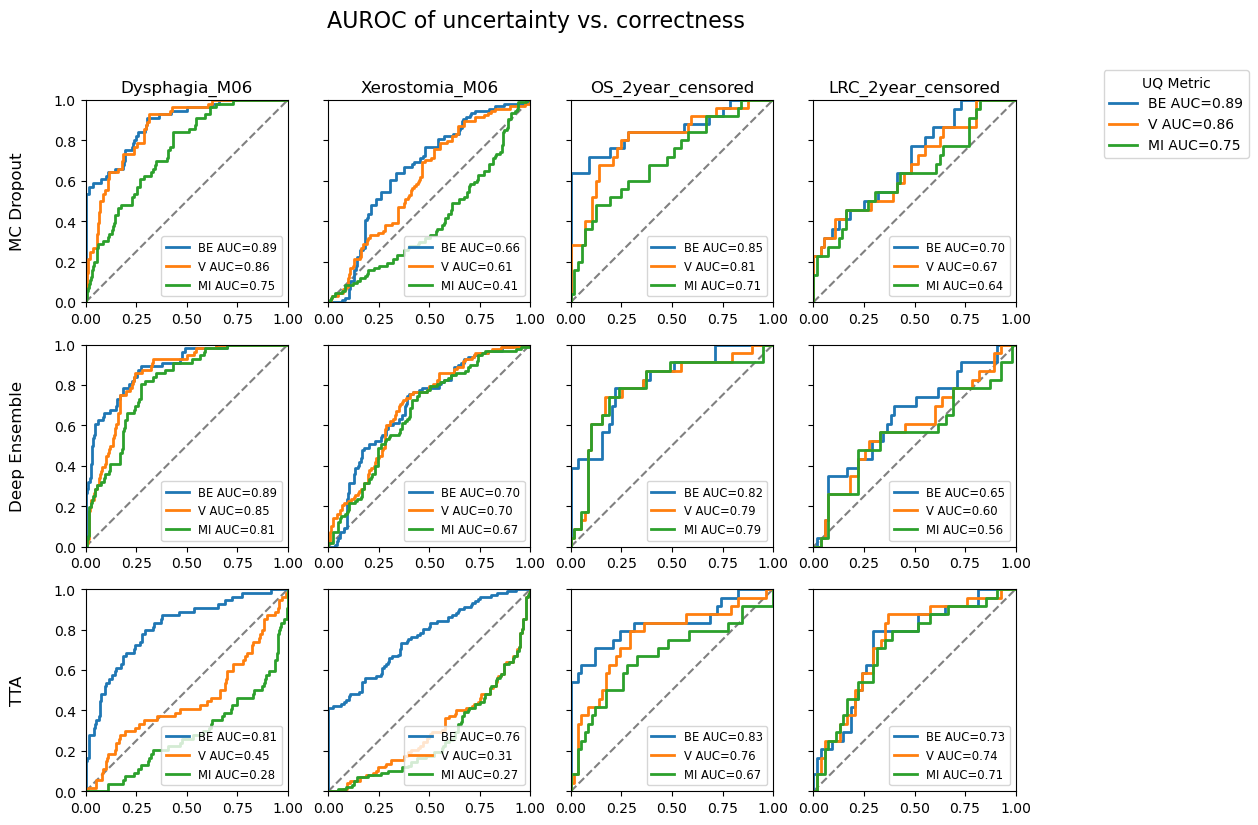

In [23]:
fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="uncertainty_and_error_AUROC", row_key="method", col_key="endpoint", normalisation_method="minmax")
plt.show()

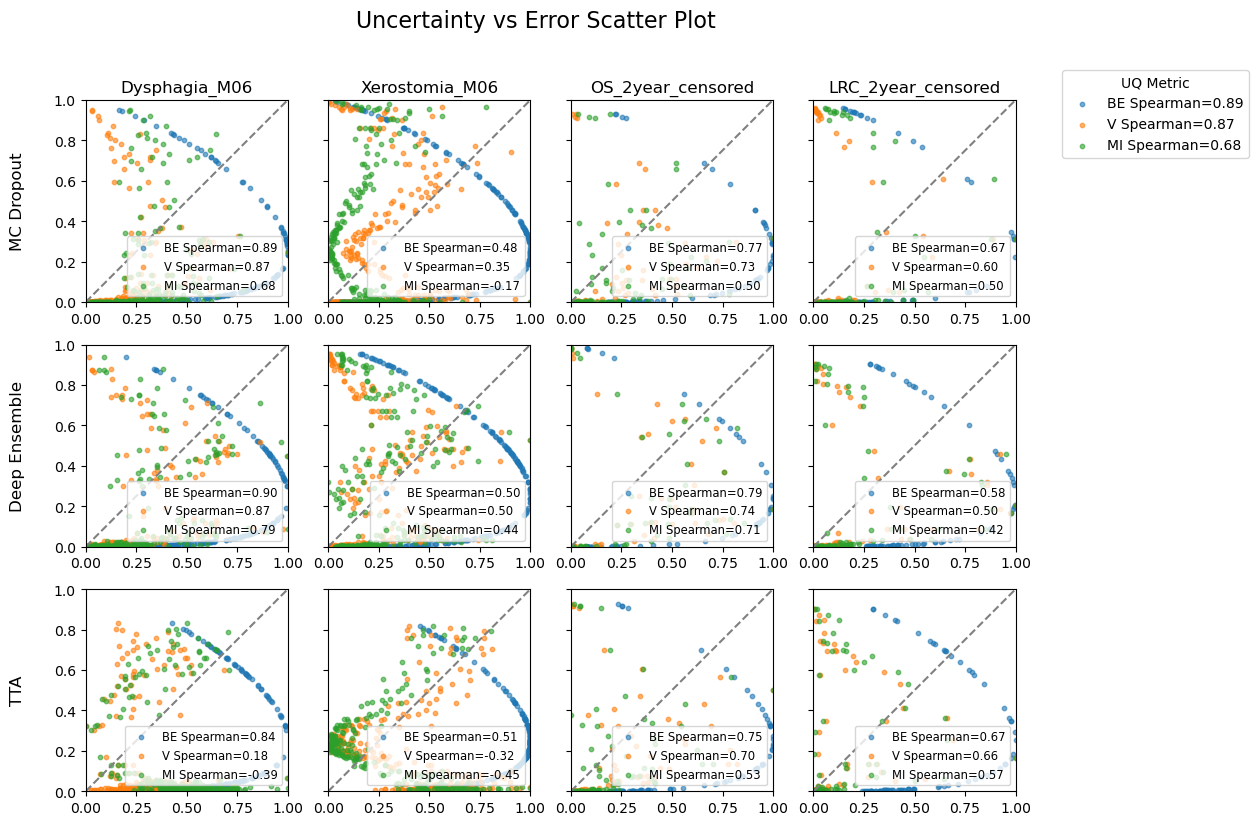

In [24]:
fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="uncertainty_error_correlation", row_key="method", col_key="endpoint", normalisation_method="minmax")
plt.show()

# CHECK METAL ARTEFACTS

In [22]:
df_dataset = pd.read_csv(r'/home/macraedc/data/uncertainty_project/UQ_metal_artefact_dataset.csv', sep=';')
df_dataset = df_dataset[['PatientID', 'CT_Artefact']]

In [23]:
df_metal = UQ_RESULTS_DICT['UQ_Metal_Artefacts']['MC Dropout']
df_metal = UQ_RESULTS_DICT['UQ_Metal_Artefacts']['Deep Ensemble']

df_metal = pd.merge(df_metal, df_dataset, how='left', on='PatientID')


KeyError: 'UQ_Metal_Artefacts'

In [24]:
from sklearn.metrics import accuracy_score

df_no_randoms = df_metal[df_metal["CT_Artefact"] != 1]
preds = df_no_randoms['Mean Prediction']
labels = df_no_randoms['True Labels']

accuracy = accuracy_score(labels, preds.round())
print(f"Accuracy: {accuracy:.3f}")


df_randoms = df_metal[df_metal["CT_Artefact"] == 1]
preds = df_randoms['Mean Prediction']
labels = df_randoms['True Labels']

accuracy = accuracy_score(labels, preds.round())
print(f"Accuracy: {accuracy:.3f}")

NameError: name 'df_metal' is not defined

In [25]:
def accuracy_by_column(df, column):
    """
    Computes accuracy for the half of samples with the highest and lowest mutual information.

    Args:
        df (pd.DataFrame): DataFrame with columns 'Mutual Information', 'Mean Prediction', 'True Labels'

    Returns:
        dict: {'high_MI_accuracy': float, 'low_MI_accuracy': float}
    """
    df_sorted = df.sort_values('Mutual Information')
    n = len(df_sorted)
    third = (n) // 2

    # Lowest MI half
    df_low_MI = df_sorted.iloc[:third]
    acc_low = (df_low_MI['Mean Prediction'].round() == df_low_MI['True Labels']).mean()

    # Highest MI half
    df_high_MI = df_sorted.iloc[-third:]
    acc_high = (df_high_MI['Mean Prediction'].round() == df_high_MI['True Labels']).mean()

    results = {f'low_{column}_accuracy': acc_low, f'high_{column}_accuracy': acc_high}

    print(results)

    #return results


accuracy_by_column(df_metal, "Mutal Information")
accuracy_by_column(df_metal, "Binary Entropy")
accuracy_by_column(df_metal, "Variance")

NameError: name 'df_metal' is not defined

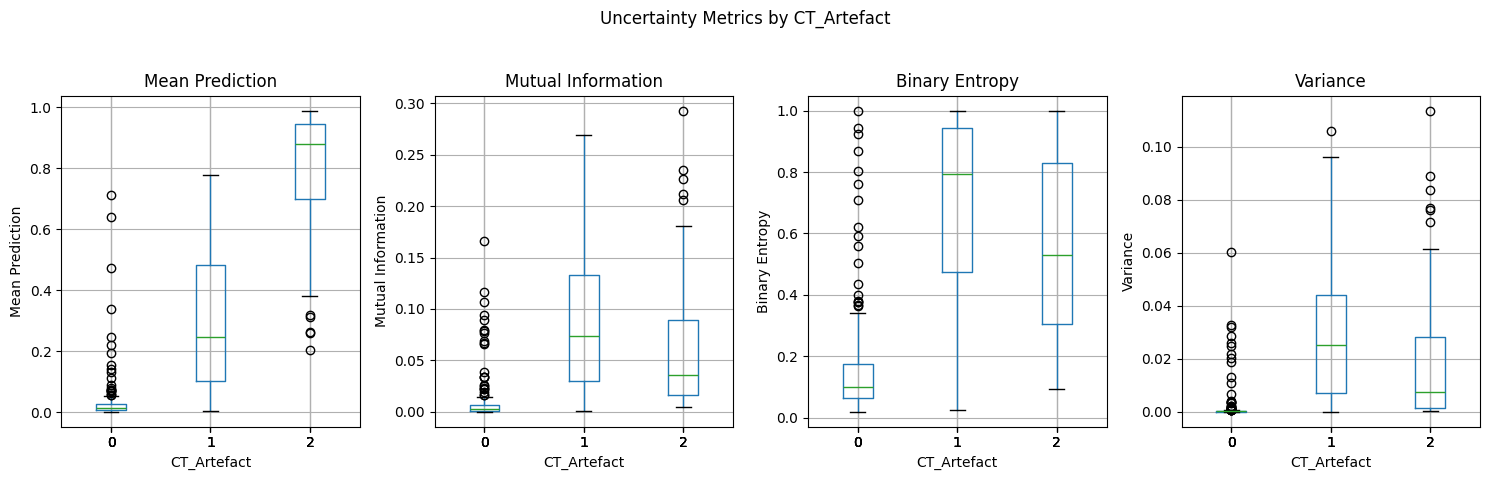

In [230]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True)

metrics = ["Mean Prediction", 'Mutual Information', 'Binary Entropy', 'Variance']
for i, metric in enumerate(metrics):
    df_metal.boxplot(column=metric, by='CT_Artefact', ax=axes[i])
    axes[i].set_title(metric)
    axes[i].set_xlabel('CT_Artefact')
    axes[i].set_ylabel(metric)

plt.suptitle('Uncertainty Metrics by CT_Artefact')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

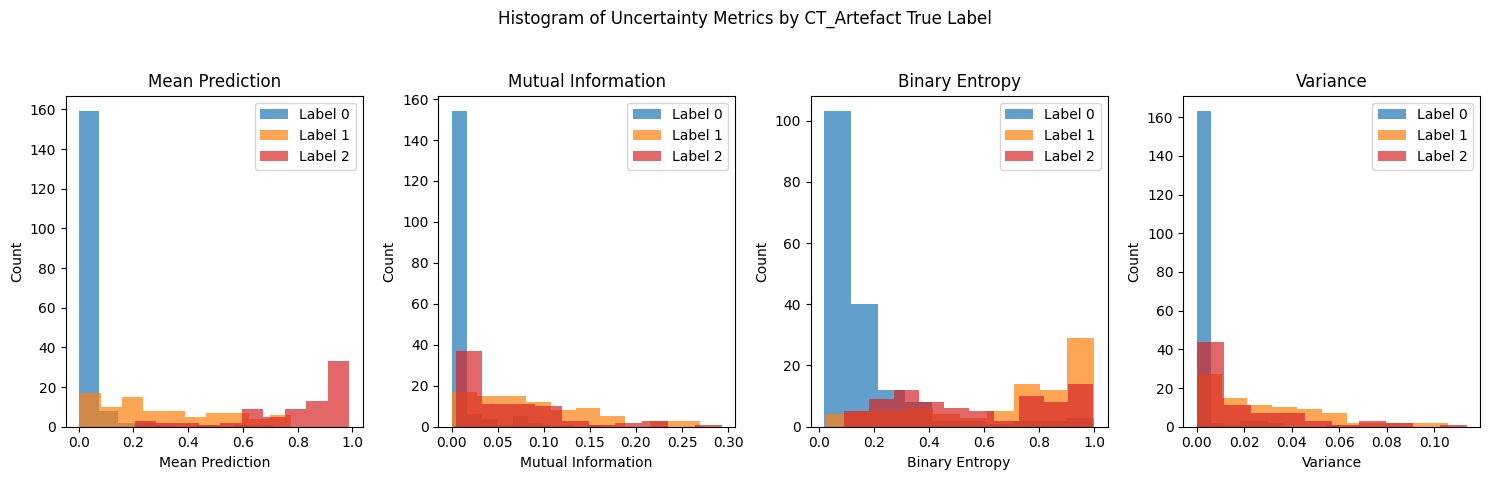

In [231]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=False)

metrics = ["Mean Prediction", 'Mutual Information', 'Binary Entropy', 'Variance']
label_colors = {0: 'C0', 1: 'C1', 2 : 'C3'}

for i, metric in enumerate(metrics):
    for label in [0, 1, 2]:
        data = df_metal[df_metal['CT_Artefact'] == label][metric]
        axes[i].hist(data, bins=10, alpha=0.7, color=label_colors[label], label=f'Label {int(label)}')
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Histogram of Uncertainty Metrics by CT_Artefact True Label')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [12]:
UQ_RESULTS_DICT.keys()

dict_keys(['Dysphagia_M06', 'Xerostomia_M06', 'OS_2year_censored', 'LRC_2year_censored', 'Taste_M06', 'UQ_Metal_Artefacts'])

In [161]:
UQ_methods_list

['MC Dropout', 'Deep Ensemble', 'TTA']

In [ ]:
from src.uncertainty.metrics.make_table import make_nested_UQ_table
from src.evaluation.metrics.calibration import ECE, ACE

metric_func  = ACE  # NOTE: NOT USED IN MAKE_TABLE.PY

df_metrics = make_nested_UQ_table(
    config,
    UQ_RESULTS_DICT,
    ENDPOINT_TYPES,
    UQ_methods_list,
    UQ_metrics_list,
    metric_func,
    N_bins = 5
)

df_metrics

,endpoint,method,uq_metric,metric_value
0,Dysphagia_M06,MC Dropout,Binary Entropy,0.085882
1,Dysphagia_M06,MC Dropout,Variance,0.002425
2,Dysphagia_M06,MC Dropout,Mutual Information,0.038929
3,Dysphagia_M06,Deep Ensemble,Binary Entropy,0.063097
4,Dysphagia_M06,Deep Ensemble,Variance,0.020847
5,Dysphagia_M06,Deep Ensemble,Mutual Information,0.010934
6,Dysphagia_M06,TTA,Binary Entropy,0.154690
7,Dysphagia_M06,TTA,Variance,0.012007
8,Dysphagia_M06,TTA,Mutual Information,0.021475
9,Xerostomia_M06,MC Dropout,Binary Entropy,0.110901
